# Problem 1 - Real GDP across US states

**Question 1.1 - downloading and computing the data**


1.1.1) Downloading the data from FRED

In [ ]:
from data_loader import load_state_data

# a. FRED API key
api_key = '6c88ec46f20df2ad295843c1c220a79b'

# b. downloading real GDP and population for all the states by importing our data loading function.
df_gdp, df_pop = load_state_data(api_key)

# c. Controlling that the data has been correctly loaded from the API
print('Real GDP — millions of chained 2017 $ (first 5 rows):')
display(df_gdp.head())
print('Population — thousands of persons (first 5 rows):')
display(df_pop.head())

Real GDP — millions of chained 2017 $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


Population — thousands of persons (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


1.1.2) Merging the data


After examining the data we expect the merged series to only contain data from 1997 to 2025 as these are the only years where both series contain data.

In [ ]:
from states import STATES

# a. We use an inner join on the year, such that we only keep observations in both series.
years = df_gdp.index.intersection(df_pop.index)
gdp = df_gdp.loc[years]
pop = df_pop.loc[years]

# b. We now drop missing observation in either series
complete = gdp.notna().all(axis=0) & pop.notna().all(axis=0)
gdp = gdp.loc[:, complete]
pop = pop.loc[:, complete]

# c. Printing what is kept and dropped
dropped = [s for s in STATES if s not in gdp.columns]
print(f'years:  {gdp.shape[0]}  ({years.min()}–{years.max()})')
print(f'states: {gdp.shape[1]}')
print(f'dropped states: {dropped if dropped else "none"}')

years:  29  (1997–2025)
states: 50
dropped states: none


1.1.3) Computing real gdp. pr person

In [10]:
# we multiply with 1000 such that we get the number in dollars pr. person
y = gdp / pop * 1_000   

# a. displaying our computations
print('Real GDP per person, $ (first 5 rows):')
display(y.tail())

Real GDP per person, $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
2021,46326.418429,70466.518738,54503.203317,45467.137652,80482.169315,69880.200221,75054.722245,74821.664859,53701.127341,59644.782127,...,62496.053232,57656.343682,64434.908012,63262.715899,51888.640655,65333.746266,80849.257701,42684.306865,56926.438867,64145.312268
2022,47243.024636,68845.471806,56145.882024,45504.587638,80439.194571,72193.827301,77195.666850,79499.627063,55587.053246,61309.029320,...,60778.568255,58818.134519,65580.844307,64187.808345,53914.677570,66731.858563,82577.604128,43714.187631,57910.870078,64789.202086
2023,48519.143781,73754.175435,57385.911276,46245.817393,81773.355891,74459.967796,77780.774209,79287.760515,57105.762910,61412.466335,...,62384.839263,59873.390699,69582.978385,65614.701592,54806.537373,68627.882118,85598.588023,45402.974855,58530.811841,68146.942015
2024,49511.268038,75957.759081,59150.757025,47605.326736,84007.305618,74950.045938,77878.370335,81276.669495,58122.776407,62249.013942,...,62255.827248,60706.459029,70946.493803,66886.022570,56299.640692,69584.309658,88576.692762,46801.180490,59488.350841,67801.616438
2025,50191.331246,77974.147870,59779.129040,48362.891764,86110.486390,76198.328799,79436.930391,82344.389180,59406.969874,62853.060158,...,62576.810460,61428.835463,71813.817555,68039.963785,57251.928527,70263.669120,89678.678468,47091.606758,60206.918479,67924.070026


1.1.4) Highest and lowest values

In [13]:
# a. Extracting the first and last years
tfirst, tlast = y.index.min(), y.index.max()

# b. Looping through the first and last periods for all states and printing the results
for t in (tfirst, tlast):
    row = y.loc[t]   

    print(f'{t}:')
    print(f'  highest: {row.idxmax()} with {row.max():,.0f} $ pr. person')
    print(f'  lowest:  {row.idxmin()} with {row.min():,.0f} $ pr. person')
    print(f'  ratio:   {row.max()/row.min():.2f}')
    print(f'  average across all states: {row.mean():,.0f} $ pr. person')
    print()

1997:
  highest: DE with 69,749 $ pr. person
  lowest:  ID with 32,063 $ pr. person
  ratio:   2.18
  average across all states: 44,593 $ pr. person

2025:
  highest: NY with 94,702 $ pr. person
  lowest:  MS with 42,434 $ pr. person
  ratio:   2.23
  average across all states: 64,674 $ pr. person



1.1.5) Plotting descriptive statistics for the states we found in 1.1.4

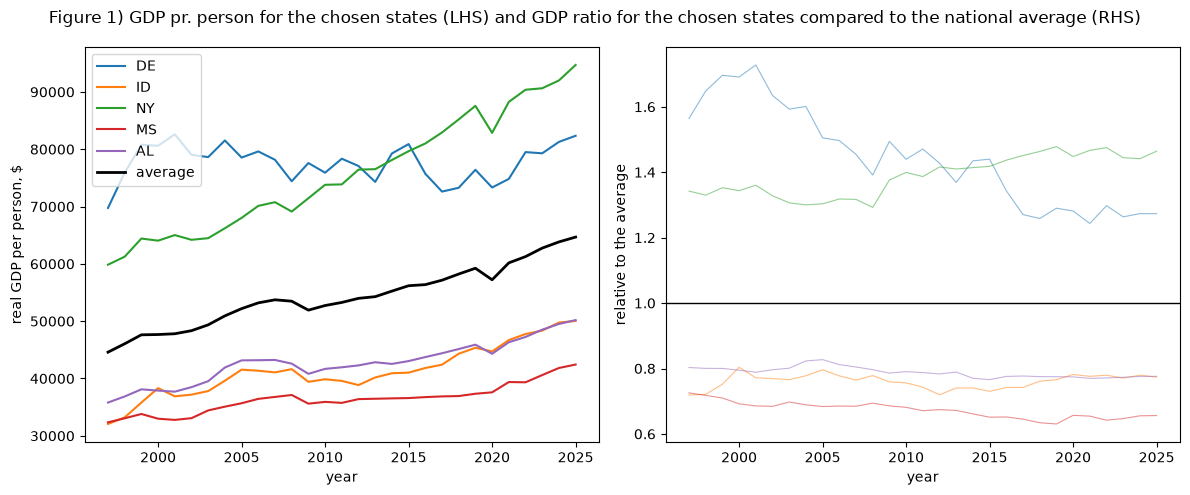

In [25]:
import matplotlib.pyplot as plt

# a. Specifying the states 
some_states = ['DE','ID','NY','MS','AL'] 

# b. yearly averages
avg = y.mean(axis=1)        

# c. GDP pr person divided by the yearly average across all states in that year
ratio = y.divide(avg, axis=0)                            

# d. specifying the plot
fig = plt.figure(figsize=(12,5))

# i. averages for the specified states
ax1 = fig.add_subplot(1,2,1)
for state in some_states:
    ax1.plot(y.index, y[state], label=state)
ax1.plot(y.index, avg, color='black', lw=2, label='average')
ax1.set_xlabel('year')
ax1.set_ylabel('real GDP per person, $')
ax1.legend(loc='upper left')

# ii: the specified states relative to the average across all states
ax2 = fig.add_subplot(1,2,2)
for state in some_states:
    ax2.plot(ratio.index, ratio[state], lw=0.8, alpha=0.5)
ax2.axhline(1, color='black', lw=1)                    
ax2.set_xlabel('year')
ax2.set_ylabel('relative to the average')

fig.suptitle("Figure 1) GDP pr. person for the chosen states (LHS) and GDP ratio for the chosen states compared to the national average (RHS)")
fig.tight_layout()

We have read this question as the second plot to only account for the handful of states as in the first plot. Here we chose the four that we found in question 1.1.4. plus Alabama. 

From panel 1, we see that all states display a clear growth in GDP pr. person. New York and Idaho has the highest growth, whereas Misssisipi and Alabama display growthpatterns that are more in line with the national average. The levels are however different. Delaware has the most fluctuating growth of them all. 

Looking at panel 2, we see how the states perform relative to the average across states, where a value of 1 represents the average. Delaware is clearly above the average throughout the period, but its relative position decreases over time. New York moves further above the average and ends at around 1.45. Idaho and Alabama remain stable at around 0.8 of the average, while Mississippi stays at the lowest level and falls slightly further behind. Overall, the figure shows that the relative development differs quite a lot across the chosen states.



**Question 1.2) Standard deviation and plotting**

1997: 0.1833
2025:  0.1786
highest: 2012 with 0.1909
lowest:  2005 with 0.1683


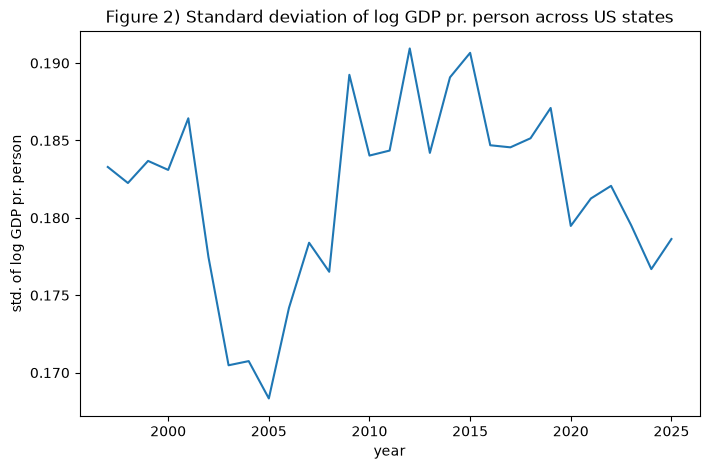

In [33]:
import numpy as np

# a. Standard deviation across states of log gdp pr. person for each year
logy = np.log(y)              
sigma = logy.std(axis=1)      

# b. plotting the standard deviation of log(GDP)
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(sigma.index, sigma)
ax.set_xlabel('year')
ax.set_ylabel('std. of log GDP pr. person')
ax.set_title('Figure 2) Standard deviation of log GDP pr. person across US states')

# b. printing our results 
print(f'{tfirst}: {sigma.loc[tfirst]:.4f}')
print(f'{tlast}:  {sigma.loc[tlast]:.4f}')
print(f'highest: {sigma.idxmax()} with {sigma.max():.4f}')
print(f'lowest:  {sigma.idxmin()} with {sigma.min():.4f}')

The overall pattern is fluctuating with no clear trend. It starts at 0.1833 in 1997 and falls to its lowest value of 0.1683 in 2005. After 2005, the standard deviation increases again and reaches its highest value of 0.1909 in 2012. From around 2019 onwards, it generally decreases, ending at 0.1786 in 2025. Interestingly we see that the smallest standard deviation in GDP pr person is in 2005, which is just before the financial crisis. Similar, the largest dispersion is in 2012 which is a few years after the financial crisis. 

**Question 1.3) Growth, speed of convergence and the half life**

level intercept (a) = 0.118
slope parameter (b) = -0.010
correlation between log(GDP) in the first year and the growth average in that year = -0.389
Speed of convergence (lambda) = 0.011
Half life (h) = 60.492


Text(0.5, 1.0, 'Figure 3) Correlation between annual growth and log(GDP) pr. person')

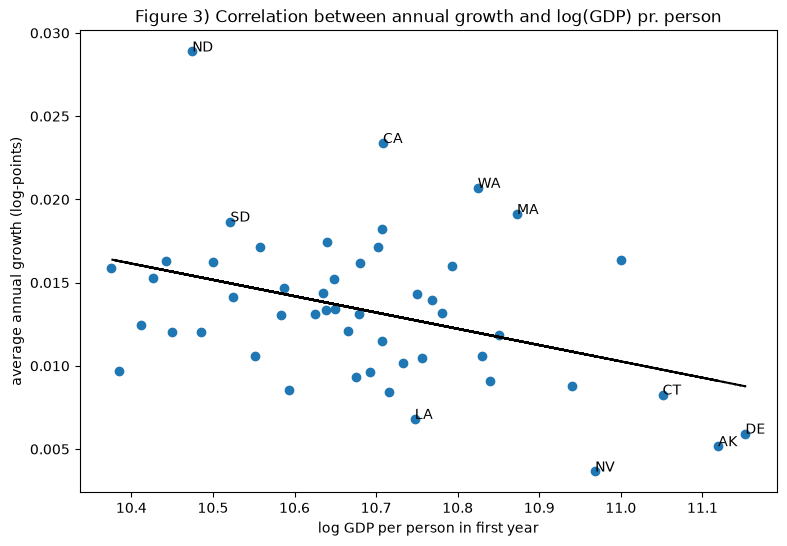

In [47]:
# a. taking the log and constructing the numerator as T
logy = np.log(y)
T = tlast - tfirst

# b. calculating the average growth rate                      
g = (logy.loc[tlast] - logy.loc[tfirst]) / T   

# c. fitting the regression line using polyfit. 
x = logy.loc[tfirst]  
b, a = np.polyfit(x, g, 1) # b specifies the slope parameter, whereas a specifies the level intercept of the OLS regression

# d. correlation between log(GDP) in the first year and the growth rate in that year
corr = x.corr(g)

# e. deriving the speed of convergence and the half life
lamb = -np.log(1 + b*T) / T
h = np.log(2) / lamb

# f. printing our computations
print(f'level intercept (a) = {a:.3f}')
print(f'slope parameter (b) = {b:.3f}')
print(f'correlation between log(GDP) in the first year and the growth average in that year = {corr:.3f}')
print(f'Speed of convergence (lambda) = {lamb:.3f}')
print(f'Half life (h) = {h:.3f}')

# g. Scatterplot with the regression line
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)
ax.scatter(x, g)
ax.plot(x, (a + b*x), color='black', ls='--')

# h. labeling the 5 highest and 5 lowest growth states in the scatterplot
for state in list(g.sort_values().index[:5]) + list(g.sort_values().index[-5:]):
    ax.annotate(state, (x[state], g[state]))

ax.set_xlabel('log GDP per person in first year')
ax.set_ylabel('average annual growth (log-points)')

plt.title("Figure 3) Correlation between annual growth and log(GDP) pr. person")


The fitted line has an intercept of a = 0.1181 and a slope of b = -0.0098. We see that the slope is negative, which indicates convergence in growth rates, since the states with the highest initial values of log(GDP) tend to have lower growth rates. This is also clear from the negative correlation of -0.389 between the average annual growth and the initial level of log(GDP)

From the slope we obtain a speed of convergence of lambda = 0.0115, corresponding to approx 1.15% per year, and a half-life of around 60.5 years. Hence from the estimated relationship, it would take roughly 60 years for half of an initial difference in GDP per person between two states to disappear. This in total indicates convergence between the states.


**Question 1.4) Regions and convergence**

South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64
           first   last  change
Midwest    0.968  1.006   0.037
Northeast  1.087  1.095   0.008
South      0.951  0.905  -0.046
West       1.029  1.045   0.017
largest move: South (-0.046)


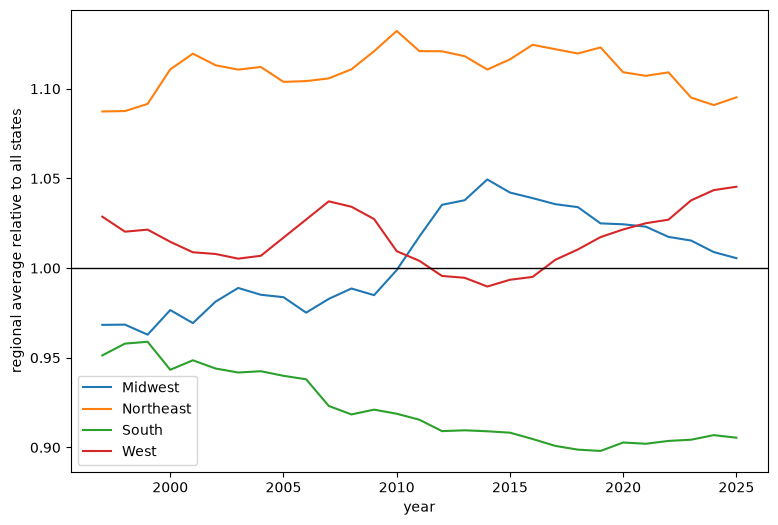

In [ ]:
from states import REGION
import pandas as pd


# a. Calculating ratio between GDP pr. persion relative to the GDP pr. person across all states
ratio = y.divide(y.mean(axis=1), axis=0)        

# b. we now group the states into their respective regions and calculate the average with each region
region_ratio = ratio.T.groupby(REGION).mean().T     

# c. how many states in each region
counts = pd.Series(REGION).loc[y.columns].value_counts()
print(counts)



# Q1.4.2) Plot the four regional series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)
for region in region_rel.columns:
    ax.plot(region_rel.index, region_rel[region], label=region)
ax.axhline(1, color='black', lw=1)              # the all-state average
ax.set_xlabel('year')
ax.set_ylabel('regional average relative to all states')
ax.legend()

# Q1.4.3) First year, last year, and the change
summary = pd.DataFrame({'first': region_rel.loc[tfirst],
                        'last':  region_rel.loc[tlast]})
summary['change'] = summary['last'] - summary['first']
print(summary.round(3))

mover = summary['change'].abs().idxmax()
print(f'largest move: {mover} ({summary.loc[mover, "change"]:+.3f})')